## XGBoost

In [ ]:
# ── Colab / Local setup ──────────────────────────────────────────────────
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    subprocess.run(["git", "clone", "https://github.com/DaTking4/ml-final-project-walmart-recruiting.git"], check=True)
    %cd ml-final-project-walmart-recruiting

    %pip install -q -r requirements.txt

    import os
    from google.colab import userdata
    os.environ["DAGSHUB_USER_TOKEN"] = userdata.get("DAGSHUB_TOKEN")
    os.environ["WANDB_API_KEY"]      = userdata.get("WANDB_API_KEY")
    os.environ["KAGGLE_API_TOKEN"]   = userdata.get("KAGGLE_API_TOKEN")

    %pip install -q kaggle
    import os
    os.makedirs("data", exist_ok=True)
    !kaggle competitions download -c walmart-recruiting-store-sales-forecasting -p data/ --quiet
    !unzip -q -o data/walmart-recruiting-store-sales-forecasting.zip -d data/

print("Running in:", "Google Colab" if IN_COLAB else "Local environment")


### 1. Setup and Imports

In [1]:
import os
import sys
import importlib
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))

repo_root = Path.cwd()
while repo_root != repo_root.parent:
    if (repo_root / "src").exists():
        sys.path.insert(0, str(repo_root))
        break
    repo_root = repo_root.parent
else:
    raise FileNotFoundError("Could not locate repo root containing 'src'.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

import mlflow
import mlflow.pyfunc
from mlflow.models import infer_signature
import joblib

import wandb

import src.mlflow_setup as mlflow_setup
importlib.reload(mlflow_setup)
init_tracking = mlflow_setup.init_tracking

from src.data_loading import load_merged
from src.transforms import apply_shared_features
from src.validation import time_based_split
from src.metrics import wmae_from_df
from src.xgb_utils import (
    add_lag_features, build_xgb_matrices, train_xgb,
    evaluate_xgb_config, XGB_FEATURE_COLS,
)
from src.pipeline.xgb_pipeline import XGBForecastPipeline

init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

if mlflow.active_run() is not None:
    mlflow.end_run()

BLUE   = "#7196C7"
PINK   = "#AE737D"
PURPLE = "#705588"
RED    = "#7E3838"
GREEN  = "#5E9D74"

REGIME_COLORS = {"underfit": PURPLE, "balanced": BLUE, "overfit": RED}
STATUS_COLORS = {"good": GREEN, "underfit": PURPLE, "overfit": RED}

print("Setup complete.")


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

/Users/macbookpro/Desktop/ml-final-project-walmart-recruiting/.venv311/lib/python3.11/site-packages/rich/live.py:26
0: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=4b21b4ca-57ce-495d-b0e6-3eddcba46d18&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=50152a6733f161a1e91462177ad9762dd451c41017aae975c019b1d3c7906a07




Accessing as dkhak22

Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Setup complete.


### 2. Configuration

In [2]:
init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

EXPERIMENT_NAME = "XGBoost_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

WANDB_ENTITY  = "dkhak22-free-university-of-tbilisi-"
WANDB_PROJECT = "walmart-sales-forecasting"

CONFIG = {
    "horizon":      26,
    "random_seed":  42,
}

MODEL_COL = "XGBoost"
FREQ      = "W-FRI"

CONFIG


Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow


2026/07/12 21:16:07 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Training' does not exist. Creating a new experiment.


{'horizon': 26, 'random_seed': 42}

### 3. Load Data

In [3]:
train_df, test_df = load_merged()

print(f"train_df: {train_df.shape}")
print(f"test_df:  {test_df.shape}")

CONFIG["horizon"] = test_df["Date"].nunique()

train_df.head()


train_df: (421570, 16)
test_df:  (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


### 4. Shared Preprocessing and Feature Engineering

In [4]:
train_feat = apply_shared_features(train_df)
test_feat  = apply_shared_features(test_df)

print(f"Columns after shared feature engineering: {train_feat.columns.tolist()}")
train_feat.head()


Columns after shared feature engineering: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Type_A', 'Type_B', 'Type_C', 'Year', 'Month', 'WeekOfYear', 'DaysSinceLastHoliday', 'DaysToNextHoliday']


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Size,Type_A,Type_B,Type_C,Year,Month,WeekOfYear,DaysSinceLastHoliday,DaysToNextHoliday
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,5,inf,7.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,6,0.0,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,7,7.0,203.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,8,14.0,196.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,3,9,21.0,189.0


### 5. Feature Decision

In [5]:
XGB_FEATURE_DECISION = {
    "feature_set": "full_exogenous",
    "uses_exogenous_features": True,
    "used_features": XGB_FEATURE_COLS,
    "reason": (
        "XGBoost is a tabular model that supports all available features. "
        "Lag features (lag_26, lag_52) capture autoregressive structure without "
        "future leakage. Rolling stats are shifted by 26 weeks before computing "
        "so they are available at the 26-week test horizon. Holiday weighting "
        "(w=5) is passed via sample_weight during training."
    ),
}

print("Feature set:", XGB_FEATURE_DECISION["feature_set"])
print("Number of features:", len(XGB_FEATURE_COLS))
print("Features:", XGB_FEATURE_COLS)


Feature set: full_exogenous
Number of features: 29
Features: ['lag_26', 'lag_52', 'rolling_mean_4', 'rolling_mean_13', 'rolling_mean_26', 'rolling_std_4', 'rolling_std_13', 'rolling_std_26', 'WeekOfYear', 'Month', 'Year', 'Type_A', 'Type_B', 'Type_C', 'Size', 'IsHoliday', 'DaysSinceLastHoliday', 'DaysToNextHoliday', 'Fuel_Price', 'Temperature', 'CPI', 'Unemployment', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Store', 'Dept']


### 6. XGBoost Lag Feature Engineering

In [6]:
# XGBoost-specific: add lag and rolling features.
# Rows with NaN lags (first 52 rows per series) are dropped at matrix-build time.
train_feat = add_lag_features(train_feat)

lag_cols = [c for c in train_feat.columns if c.startswith("lag_") or c.startswith("rolling_")]
print("Lag / rolling columns added:", lag_cols)
print(f"Rows with any NaN in lag cols: {train_feat[lag_cols].isna().any(axis=1).sum():,}")
train_feat.head()


Lag / rolling columns added: ['lag_26', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_13', 'rolling_std_13', 'rolling_mean_26', 'rolling_std_26']
Rows with any NaN in lag cols: 160,487


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,DaysSinceLastHoliday,DaysToNextHoliday,lag_26,lag_52,rolling_mean_4,rolling_std_4,rolling_mean_13,rolling_std_13,rolling_mean_26,rolling_std_26
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,inf,7.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,7.0,203.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,14.0,196.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,21.0,189.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0


### 7. Train / Validation Split and Matrix Build

In [7]:
train_part, valid_part = time_based_split(
    train_feat,
    valid_weeks=CONFIG["horizon"],
)

print(f"Train part: {train_part['Date'].min().date()} -> {train_part['Date'].max().date()}")
print(f"Valid part: {valid_part['Date'].min().date()} -> {valid_part['Date'].max().date()}")

X_train, y_train, w_train, train_clean = build_xgb_matrices(train_part, XGB_FEATURE_COLS)
X_val,   y_val,   w_val,   val_clean   = build_xgb_matrices(valid_part, XGB_FEATURE_COLS)

print(f"\nX_train: {X_train.shape}  (after dropping NaN lag rows)")
print(f"X_val:   {X_val.shape}")
print(f"Holiday rows in train: {(w_train == 5.0).sum():,}")
print(f"Holiday rows in val:   {(w_val == 5.0).sum():,}")


def fit_gap_pct(train_wmae, val_wmae):
    if pd.isna(train_wmae) or train_wmae == 0:
        return float("nan")
    return ((val_wmae - train_wmae) / train_wmae) * 100


def classify_fit_status(train_wmae, val_wmae):
    gap = fit_gap_pct(train_wmae, val_wmae)
    if pd.isna(gap):
        return "unknown"
    if gap > 25:
        return "overfit"
    if gap < -10:
        return "underfit"
    return "good"


Train part: 2010-02-05 -> 2012-01-27
Valid part: 2012-02-03 -> 2012-10-26

X_train: (147894, 29)  (after dropping NaN lag rows)
X_val:   (113189, 29)
Holiday rows in train: 11,396
Holiday rows in val:   5,807


### 8. Sanity Check

In [8]:
sanity_config = {
    "n_estimators": 10,
    "max_depth": 3,
    "learning_rate": 0.3,
}

sanity_model, sanity_train_wmae, sanity_val_wmae = evaluate_xgb_config(
    config=sanity_config,
    X_train=X_train.head(500),
    y_train=y_train.head(500),
    w_train=w_train[:500],
    X_val=X_val.head(200),
    val_meta=val_clean.head(200),
    model_col=MODEL_COL,
)

print(f"Sanity train WMAE: {sanity_train_wmae:,.2f}")
print(f"Sanity val   WMAE: {sanity_val_wmae:,.2f}")
print("Sanity check passed.")


Sanity train WMAE: 1,994.53
Sanity val   WMAE: 2,866.80
Sanity check passed.


### 9. Baseline Run

In [9]:
baseline_config = {
    "label":         "baseline_xgb",
    "regime":        "baseline",
    "n_estimators":  300,
    "max_depth":     5,
    "learning_rate": 0.05,
    "subsample":     0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "reg_lambda":    1.0,
    "reg_alpha":     0.0,
}

with mlflow.start_run(run_name="XGBoost_Baseline") as run:
    wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name="XGBoost_Baseline",
        group="XGBoost",
        job_type="baseline",
        tags=["XGBoost", "baseline", "full_exogenous"],
        config={**CONFIG, **baseline_config, **XGB_FEATURE_DECISION},
        reinit=True,
    )

    try:
        baseline_model, baseline_train_wmae, baseline_val_wmae = evaluate_xgb_config(
            config=baseline_config,
            X_train=X_train,
            y_train=y_train,
            w_train=w_train,
            X_val=X_val,
            val_meta=val_clean,
            model_col=MODEL_COL,
        )

        gap = fit_gap_pct(baseline_train_wmae, baseline_val_wmae)
        status = classify_fit_status(baseline_train_wmae, baseline_val_wmae)

        mlflow.log_params({k: v for k, v in baseline_config.items() if k not in ("label", "regime")})
        mlflow.log_params({
            "model":         "XGBoost",
            "feature_set":   XGB_FEATURE_DECISION["feature_set"],
            "n_features":    len(XGB_FEATURE_COLS),
            "gradient_logging_applicable": False,
        })
        mlflow.log_metrics({
            "train_wmae": baseline_train_wmae,
            "val_wmae":   baseline_val_wmae,
            "gap_pct":    gap,
        })

        wandb.log({
            "train_wmae": baseline_train_wmae,
            "val_wmae":   baseline_val_wmae,
            "gap_pct":    gap,
            "status":     status,
        })

        print(f"Baseline train WMAE: {baseline_train_wmae:,.2f}")
        print(f"Baseline val   WMAE: {baseline_val_wmae:,.2f}")
        print(f"Gap: {gap:.1f}%  Status: {status}")

    finally:
        wandb.finish()


wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: dkhak22 (dkhak22-free-university-of-tbilisi-). Use `wandb login --relogin` to force relogin
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


Baseline train WMAE: 1,587.36
Baseline val   WMAE: 1,800.42
Gap: 13.4%  Status: good


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
2026/07/12 21:16:43 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_Baseline at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/e64d1fd284ac4c79b862010c2b633caa.
2026/07/12 21:16:43 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.


### 10. Hyperparameter Grid

In [10]:
param_grid = [
    # ── Underfit (shallow trees, few estimators) ────────────────────────────
    {"n_estimators": 50,  "max_depth": 2, "learning_rate": 0.3,  "subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 20, "reg_lambda": 10.0, "reg_alpha": 0.0, "label": "underfit_1", "regime": "underfit"},
    {"n_estimators": 50,  "max_depth": 2, "learning_rate": 0.3,  "subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 50, "reg_lambda": 10.0, "reg_alpha": 5.0, "label": "underfit_2", "regime": "underfit"},
    {"n_estimators": 30,  "max_depth": 2, "learning_rate": 0.5,  "subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 50, "reg_lambda": 20.0, "reg_alpha": 0.0, "label": "underfit_3", "regime": "underfit"},
    {"n_estimators": 100, "max_depth": 2, "learning_rate": 0.3,  "subsample": 1.0, "colsample_bytree": 0.5, "min_child_weight": 30, "reg_lambda": 10.0, "reg_alpha": 0.0, "label": "underfit_4", "regime": "underfit"},
    {"n_estimators": 50,  "max_depth": 3, "learning_rate": 0.3,  "subsample": 0.5, "colsample_bytree": 0.5, "min_child_weight": 50, "reg_lambda": 5.0,  "reg_alpha": 0.0, "label": "underfit_5", "regime": "underfit"},
    {"n_estimators": 30,  "max_depth": 2, "learning_rate": 0.5,  "subsample": 0.5, "colsample_bytree": 1.0, "min_child_weight": 100,"reg_lambda": 20.0, "reg_alpha": 10.0,"label": "underfit_6", "regime": "underfit"},
    # ── Balanced ────────────────────────────────────────────────────────────
    {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "balanced_1",  "regime": "balanced"},
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "balanced_2",  "regime": "balanced"},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "balanced_3",  "regime": "balanced"},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.7, "colsample_bytree": 0.7, "min_child_weight": 10, "reg_lambda": 2.0,  "reg_alpha": 0.1, "label": "balanced_4",  "regime": "balanced"},
    {"n_estimators": 500, "max_depth": 4, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "balanced_5",  "regime": "balanced"},
    {"n_estimators": 500, "max_depth": 5, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.7, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "balanced_6",  "regime": "balanced"},
    {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "balanced_7",  "regime": "balanced"},
    {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.7, "colsample_bytree": 0.7, "min_child_weight": 10, "reg_lambda": 3.0,  "reg_alpha": 0.5, "label": "balanced_8",  "regime": "balanced"},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1,  "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "balanced_9",  "regime": "balanced"},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1,  "subsample": 0.7, "colsample_bytree": 0.8, "min_child_weight": 10, "reg_lambda": 2.0,  "reg_alpha": 0.0, "label": "balanced_10", "regime": "balanced"},
    {"n_estimators": 400, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.9, "min_child_weight": 5,  "reg_lambda": 1.5,  "reg_alpha": 0.0, "label": "balanced_11", "regime": "balanced"},
    {"n_estimators": 400, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.9, "min_child_weight": 5,  "reg_lambda": 1.5,  "reg_alpha": 0.0, "label": "balanced_12", "regime": "balanced"},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 1.0, "label": "balanced_13", "regime": "balanced"},
    {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.6, "min_child_weight": 5,  "reg_lambda": 2.0,  "reg_alpha": 0.5, "label": "balanced_14", "regime": "balanced"},
    {"n_estimators": 500, "max_depth": 5, "learning_rate": 0.03, "subsample": 0.7, "colsample_bytree": 0.7, "min_child_weight": 10, "reg_lambda": 2.0,  "reg_alpha": 0.5, "label": "balanced_15", "regime": "balanced"},
    {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1,  "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "balanced_16", "regime": "balanced"},
    {"n_estimators": 400, "max_depth": 6, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "balanced_17", "regime": "balanced"},
    {"n_estimators": 500, "max_depth": 6, "learning_rate": 0.03, "subsample": 0.7, "colsample_bytree": 0.7, "min_child_weight": 10, "reg_lambda": 3.0,  "reg_alpha": 1.0, "label": "balanced_18", "regime": "balanced"},
    # ── Overfit (deep trees, many estimators, low LR, no regularisation) ────
    {"n_estimators": 2000, "max_depth": 8,  "learning_rate": 0.01, "subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 1, "reg_lambda": 0.0, "reg_alpha": 0.0, "label": "overfit_1", "regime": "overfit"},
    {"n_estimators": 1000, "max_depth": 10, "learning_rate": 0.01, "subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 1, "reg_lambda": 0.0, "reg_alpha": 0.0, "label": "overfit_2", "regime": "overfit"},
    {"n_estimators": 2000, "max_depth": 10, "learning_rate": 0.01, "subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 1, "reg_lambda": 0.0, "reg_alpha": 0.0, "label": "overfit_3", "regime": "overfit"},
    {"n_estimators": 1000, "max_depth": 8,  "learning_rate": 0.005,"subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 1, "reg_lambda": 0.0, "reg_alpha": 0.0, "label": "overfit_4", "regime": "overfit"},
    {"n_estimators": 2000, "max_depth": 8,  "learning_rate": 0.005,"subsample": 0.9, "colsample_bytree": 0.9, "min_child_weight": 1, "reg_lambda": 0.1, "reg_alpha": 0.0, "label": "overfit_5", "regime": "overfit"},
    {"n_estimators": 3000, "max_depth": 6,  "learning_rate": 0.005,"subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 1, "reg_lambda": 0.0, "reg_alpha": 0.0, "label": "overfit_6", "regime": "overfit"},
]

print(f"Total configs: {len(param_grid)}")
regime_counts = {r: sum(1 for c in param_grid if c['regime'] == r) for r in ['underfit', 'balanced', 'overfit']}
print("By regime:", regime_counts)


Total configs: 30
By regime: {'underfit': 6, 'balanced': 18, 'overfit': 6}


### 11. XGBoost Experiments

In [11]:
results      = []
best_val_wmae = float("inf")
best_run_id   = None
best_label    = None
best_model    = None

with mlflow.start_run(run_name="XGBoost_HyperparamSweep") as parent_run:
    mlflow.log_param("n_configs",    len(param_grid))
    mlflow.log_param("model",        "XGBoost")
    mlflow.log_param("feature_set",  XGB_FEATURE_DECISION["feature_set"])
    mlflow.log_param("n_features",   len(XGB_FEATURE_COLS))
    mlflow.log_param("gradient_logging_applicable", False)

    for idx, original_config in enumerate(param_grid, start=1):
        config = original_config.copy()
        label  = config.pop("label")
        regime = config.pop("regime")

        with mlflow.start_run(run_name=f"XGBoost_{label}", nested=True) as nested_run:
            wandb.init(
                entity=WANDB_ENTITY,
                project=WANDB_PROJECT,
                name=f"XGBoost_{label}",
                group="XGBoost",
                job_type="hyperparam_sweep",
                tags=["XGBoost", regime],
                config={**CONFIG, **config, "label": label, "regime": regime},
                reinit=True,
            )

            try:
                model, train_wmae, val_wmae = evaluate_xgb_config(
                    config=config,
                    X_train=X_train,
                    y_train=y_train,
                    w_train=w_train,
                    X_val=X_val,
                    val_meta=val_clean,
                    model_col=MODEL_COL,
                )

                gap    = fit_gap_pct(train_wmae, val_wmae)
                status = classify_fit_status(train_wmae, val_wmae)

                mlflow.log_params({**config, "label": label, "regime": regime,
                                   "feature_set": XGB_FEATURE_DECISION["feature_set"]})
                mlflow.log_metrics({"train_wmae": train_wmae, "val_wmae": val_wmae, "gap_pct": gap})

                wandb.log({"train_wmae": train_wmae, "val_wmae": val_wmae,
                           "gap_pct": gap, "status": status})

                results.append({
                    "label": label, "regime": regime, "status": status,
                    "feature_set": XGB_FEATURE_DECISION["feature_set"],
                    **config,
                    "train_wmae": train_wmae, "val_wmae": val_wmae, "gap_pct": gap,
                    "run_id": nested_run.info.run_id,
                })

                if val_wmae < best_val_wmae:
                    best_val_wmae = val_wmae
                    best_run_id   = nested_run.info.run_id
                    best_label    = label
                    best_model    = model

                print(f"[{idx:02d}/{len(param_grid)}] {label:<16} train={train_wmae:,.0f}  val={val_wmae:,.0f}  gap={gap:+.1f}%  {status}")

            except Exception as exc:
                print(f"[{idx:02d}/{len(param_grid)}] {label} FAILED: {exc}")
                mlflow.log_param("error", str(exc))

            finally:
                wandb.finish()


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


[01/30] underfit_1       train=2,330  val=2,111  gap=-9.4%  good


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
2026/07/12 21:17:41 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_underfit_1 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/70189ccf94054a72aa89b40bd89fc26b.
2026/07/12 21:17:41 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't imp

[02/30] underfit_2       train=2,322  val=2,097  gap=-9.7%  good


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
2026/07/12 21:17:47 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_underfit_2 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/8ee76dda9f40423398d48b5cc4594cc6.
2026/07/12 21:17:47 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't imp

...

wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
2026/07/12 21:22:36 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_overfit_4 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/9cf775e68734482f8bbb7510abc56ba4.
2026/07/12 21:22:36 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't impo

[29/30] overfit_5        train=1,212  val=1,710  gap=+41.0%  overfit


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
2026/07/12 21:23:02 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_overfit_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/981371efb7984ca4a06027503a52c047.
2026/07/12 21:23:02 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't impo

[30/30] overfit_6        train=1,429  val=1,765  gap=+23.5%  good


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
2026/07/12 21:23:26 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_overfit_6 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/2a2b3e6ece1a43bca7f7f4035133e44f.
2026/07/12 21:23:26 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.
2026/07/12 21:23:26 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_HyperparamSweep at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/029af7cfc37b4804a5b0c52643298be1.
2026/07/12 21:23:26 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml

### 12. Results

In [12]:
results_df = pd.DataFrame(results).sort_values("val_wmae").reset_index(drop=True)

display_cols = [
    "label", "regime", "status",
    "n_estimators", "max_depth", "learning_rate",
    "subsample", "colsample_bytree", "min_child_weight",
    "reg_lambda", "reg_alpha",
    "train_wmae", "val_wmae", "gap_pct",
]

display(results_df[display_cols].head(15))

os.makedirs("reports", exist_ok=True)
results_path = "reports/xgboost_results.csv"
results_df.to_csv(results_path, index=False)

with mlflow.start_run(run_id=parent_run.info.run_id):
    mlflow.log_artifact(results_path)
    mlflow.log_metric("best_val_wmae", best_val_wmae)

print(f"\nBest: {best_label}  val_wmae={best_val_wmae:,.2f}")


,label,regime,status,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda,reg_alpha,train_wmae,val_wmae,gap_pct
0,overfit_5,overfit,overfit,2000,8,0.005,0.9,0.9,1,0.1,0.0,1212.483292,1709.593236,40.999323
1,overfit_4,overfit,good,1000,8,0.005,1.0,1.0,1,0.0,0.0,1407.219442,1723.548708,22.479029
2,overfit_2,overfit,overfit,1000,10,0.010,1.0,1.0,1,0.0,0.0,893.186702,1723.901231,93.005698
3,balanced_18,balanced,good,500,6,0.030,0.7,0.7,10,3.0,1.0,1463.363139,1745.217574,19.260731
4,overfit_3,overfit,overfit,2000,10,0.010,1.0,1.0,1,0.0,0.0,690.106382,1747.575512,153.232771
5,overfit_1,overfit,overfit,2000,8,0.010,1.0,1.0,1,0.0,0.0,1023.504570,1750.277473,71.008271
6,balanced_8,balanced,good,300,6,0.050,0.7,0.7,10,3.0,0.5,1469.823624,1751.162134,19.140971
7,balanced_17,balanced,good,400,6,0.030,0.8,0.8,5,1.0,0.0,1485.558932,1756.147381,18.214589
8,balanced_14,balanced,good,300,6,0.050,0.8,0.6,5,2.0,0.5,1448.949688,1757.912298,21.323212
9,overfit_6,overfit,good,3000,6,0.005,1.0,1.0,1,0.0,0.0,1429.206326,1765.002154,23.495266


2026/07/12 21:23:47 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_HyperparamSweep at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/029af7cfc37b4804a5b0c52643298be1.
2026/07/12 21:23:47 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.



Best: overfit_5  val_wmae=1,709.59


### 13. Plots

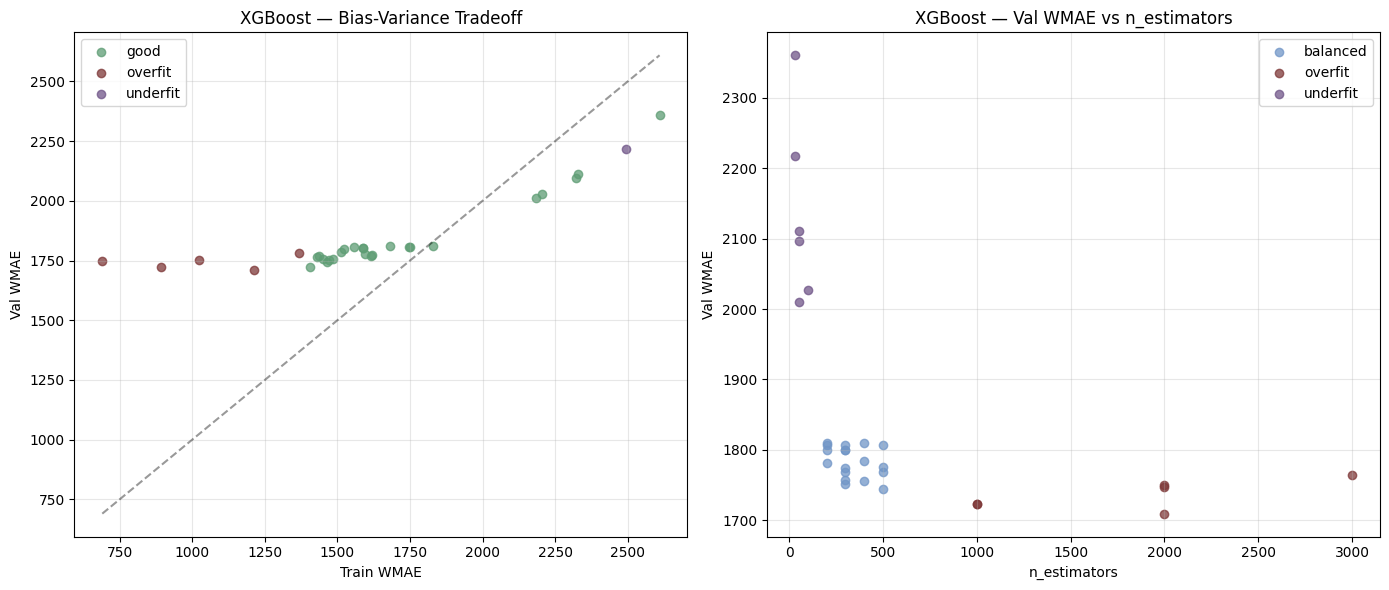

2026/07/12 21:23:55 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_overfit_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/981371efb7984ca4a06027503a52c047.
2026/07/12 21:23:55 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.


In [13]:
os.makedirs("Plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for status, sdf in results_df.groupby("status"):
    axes[0].scatter(sdf["train_wmae"], sdf["val_wmae"],
                    c=STATUS_COLORS.get(status, BLUE), alpha=0.75, label=status)

lo = float(results_df[["train_wmae", "val_wmae"]].min().min())
hi = float(results_df[["train_wmae", "val_wmae"]].max().max())
axes[0].plot([lo, hi], [lo, hi], "k--", alpha=0.4)
axes[0].set_xlabel("Train WMAE"); axes[0].set_ylabel("Val WMAE")
axes[0].set_title("XGBoost — Bias-Variance Tradeoff")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for regime, rdf in results_df.groupby("regime"):
    axes[1].scatter(rdf["n_estimators"], rdf["val_wmae"],
                    c=REGIME_COLORS.get(regime, BLUE), alpha=0.75, label=regime)

axes[1].set_xlabel("n_estimators"); axes[1].set_ylabel("Val WMAE")
axes[1].set_title("XGBoost — Val WMAE vs n_estimators")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = "Plots/xgboost_sweep.png"
plt.savefig(plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(plot_path)


### 14. Error Analysis

In [14]:
val_clean_copy = val_clean.copy()
val_clean_copy[MODEL_COL] = best_model.predict(X_val)
val_clean_copy["abs_error"] = (val_clean_copy["Weekly_Sales"] - val_clean_copy[MODEL_COL]).abs()

worst_store_dept = (
    val_clean_copy.groupby(["Store", "Dept"])["abs_error"]
    .mean().sort_values(ascending=False).head(15)
)
display(worst_store_dept)

holiday_error = val_clean_copy.groupby("IsHoliday")["abs_error"].mean()
display(holiday_error)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_metric("holiday_week_mae",     float(val_clean_copy[val_clean_copy["IsHoliday"] == 1]["abs_error"].mean()))
    mlflow.log_metric("non_holiday_week_mae", float(val_clean_copy[val_clean_copy["IsHoliday"] == 0]["abs_error"].mean()))


Store  Dept
14     92      29864.033173
       95      21928.184744
18     92      19444.034327
10     72      16827.250489
38     38      15223.366222
14     90      15172.461691
10     18      12666.558243
14     72      12574.992196
       38      12328.552155
20     72      12139.628662
13     1       12043.371234
20     38      11846.547620
31     95      11029.122877
       92      10948.224527
35     72      10517.442784
Name: abs_error, dtype: float64

IsHoliday
0    1699.731835
1    1746.064285
Name: abs_error, dtype: float64

2026/07/12 21:24:08 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_overfit_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/981371efb7984ca4a06027503a52c047.
2026/07/12 21:24:08 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.


### 15. Error Plots

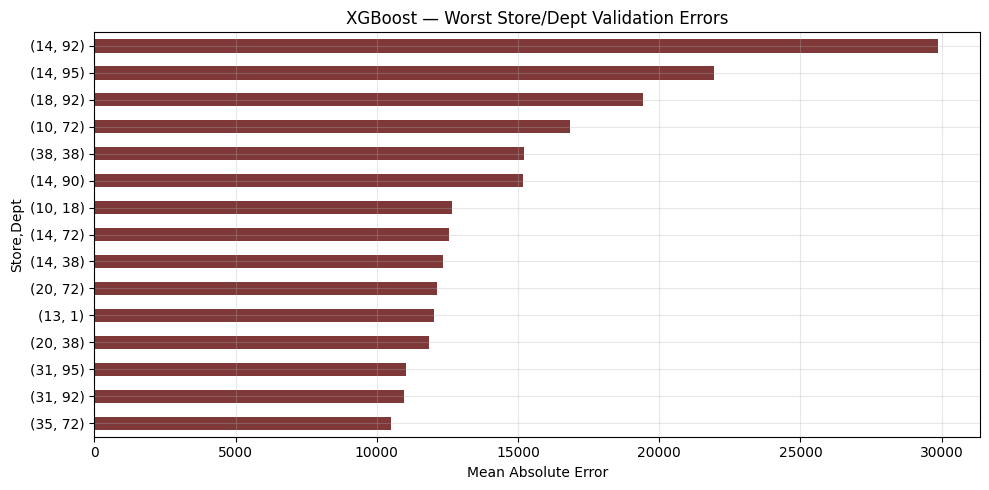

2026/07/12 21:24:12 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_overfit_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/981371efb7984ca4a06027503a52c047.
2026/07/12 21:24:12 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
worst_store_dept.sort_values().plot(kind="barh", ax=ax, color=RED)
ax.set_xlabel("Mean Absolute Error")
ax.set_title("XGBoost — Worst Store/Dept Validation Errors")
ax.grid(True, alpha=0.3)
plt.tight_layout()
error_plot_path = "Plots/xgboost_worst_store_dept.png"
plt.savefig(error_plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(error_plot_path)


### 16. Feature Importance

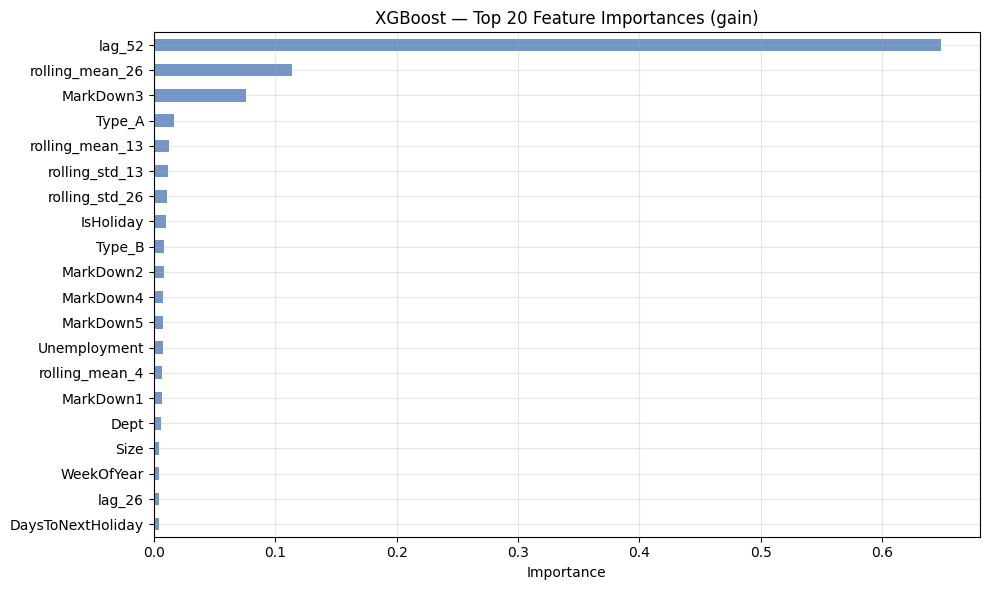

2026/07/12 21:24:28 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_overfit_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/981371efb7984ca4a06027503a52c047.
2026/07/12 21:24:28 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.


lag_52               0.648053
rolling_mean_26      0.113981
MarkDown3            0.075500
Type_A               0.016408
rolling_mean_13      0.012847
rolling_std_13       0.011274
rolling_std_26       0.010915
IsHoliday            0.010227
Type_B               0.008157
MarkDown2            0.008154
MarkDown4            0.007874
MarkDown5            0.007790
Unemployment         0.007745
rolling_mean_4       0.006696
MarkDown1            0.006464
Dept                 0.005899
Size                 0.004627
WeekOfYear           0.004538
lag_26               0.004473
DaysToNextHoliday    0.004328
dtype: float32

In [16]:
importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
importances.sort_values().plot(kind="barh", ax=ax, color=BLUE)
ax.set_title("XGBoost — Top 20 Feature Importances (gain)")
ax.set_xlabel("Importance")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fi_path = "Plots/xgboost_feature_importance.png"
plt.savefig(fi_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(fi_path)
    for feat, imp in importances.items():
        mlflow.log_metric(f"fi_{feat}", float(imp))

display(importances)


### 17. Best Model — Final Training and Registration

In [17]:
print("Best label:",           best_label)
print("Best run id:",          best_run_id)
print("Best validation WMAE:", best_val_wmae)

assert best_label  is not None
assert best_run_id is not None

best_row = results_df[results_df["label"] == best_label].iloc[0]
best_params = {
    "n_estimators":     int(best_row["n_estimators"]),
    "max_depth":        int(best_row["max_depth"]),
    "learning_rate":    float(best_row["learning_rate"]),
    "subsample":        float(best_row["subsample"]),
    "colsample_bytree": float(best_row["colsample_bytree"]),
    "min_child_weight": int(best_row["min_child_weight"]),
    "reg_lambda":       float(best_row["reg_lambda"]),
    "reg_alpha":        float(best_row["reg_alpha"]),
}
print("Best params:"); display(best_params)

fallback_by_id = (
    train_feat.assign(
        unique_id=train_feat["Store"].astype(str) + "_" + train_feat["Dept"].astype(str)
    ).sort_values("Date").groupby("unique_id")["Weekly_Sales"].last().astype(float).to_dict()
)
global_fallback = float(train_feat["Weekly_Sales"].median())

# train_tail: last 52 rows per series (needed for lag computation at test time)
train_tail = (
    train_feat.sort_values(["Store", "Dept", "Date"])
    .groupby(["Store", "Dept"], group_keys=False)
    .tail(52)
    .reset_index(drop=True)
)

# Retrain final model on full training data
X_full, y_full, w_full, _ = build_xgb_matrices(train_feat, XGB_FEATURE_COLS)

with mlflow.start_run(run_name="XGBoost_FinalModel") as final_run:
    wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name="XGBoost_FinalModel",
        group="XGBoost",
        job_type="final_training",
        tags=["XGBoost", "final"],
        config={**CONFIG, **best_params, "best_val_wmae": best_val_wmae},
        reinit=True,
    )

    try:
        final_model = train_xgb(X_full, y_full, w_full, best_params)

        os.makedirs("artifacts", exist_ok=True)
        xgb_model_path = "artifacts/xgb_model.joblib"
        joblib.dump({
            "model":          final_model,
            "feature_cols":   XGB_FEATURE_COLS,
            "train_tail":     train_tail,
            "fallback_by_id": fallback_by_id,
            "global_fallback":global_fallback,
        }, xgb_model_path)

        pipeline = XGBForecastPipeline(
            feature_cols=XGB_FEATURE_COLS,
            fallback_by_id=fallback_by_id,
            global_fallback=global_fallback,
        )
        pipeline.model      = final_model
        pipeline.train_tail = train_tail

        test_enriched = apply_shared_features(test_df)
        sample_input  = test_enriched.head(5)
        sample_output = pipeline.predict(None, sample_input)
        signature     = infer_signature(sample_input, sample_output)

        mlflow.log_params({**best_params, "best_label": best_label,
                           "feature_set": XGB_FEATURE_DECISION["feature_set"]})
        mlflow.log_metric("best_val_wmae", best_val_wmae)
        mlflow.log_metric("n_train_rows",  len(X_full))

        model_uri = mlflow.pyfunc.log_model(
            artifact_path="xgb_model",
            python_model=pipeline,
            artifacts={"xgb_model_path": xgb_model_path},
            signature=signature,
            registered_model_name="XGBoost_WalmartForecast",
        ).model_uri

        wandb.log({"best_val_wmae": best_val_wmae, "n_train_rows": len(X_full)})
        print(f"Model registered. URI: {model_uri}")

    finally:
        wandb.finish()


Best label: overfit_5
Best run id: 981371efb7984ca4a06027503a52c047
Best validation WMAE: 1709.593235567767
Best params:


{'n_estimators': 2000,
 'max_depth': 8,
 'learning_rate': 0.005,
 'subsample': 0.9,
 'colsample_bytree': 0.9,
 'min_child_weight': 1,
 'reg_lambda': 0.1,
 'reg_alpha': 0.0}

wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
/Users/macbookpro/Desktop/ml-final-project-walmart-recruiting/.venv311/lib/python3.11/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these col

Model registered. URI: runs:/7ed1a9ba1abe43bd8487be259a1f75a9/xgb_model


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
2026/07/12 21:32:33 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_FinalModel at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/7ed1a9ba1abe43bd8487be259a1f75a9.
2026/07/12 21:32:33 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.


### 18. Test Loading

In [18]:
loaded_model = mlflow.pyfunc.load_model(model_uri)

test_enriched = apply_shared_features(test_df)
loaded_preds  = loaded_model.predict(test_enriched)

print(type(loaded_preds))
print(loaded_preds.shape)
display(loaded_preds.head())


<class 'pandas.core.frame.DataFrame'>
(115064, 2)


,Id,Weekly_Sales
0,1_1_2012-11-02,46890.644531
1,1_1_2012-11-09,20651.115234
2,1_1_2012-11-16,21189.953125
3,1_1_2012-11-23,23258.861328
4,1_1_2012-11-30,26791.285156
